<a href="https://colab.research.google.com/github/fadeeva/portfoli_o_o_ptimisation/blob/main/Step_01__Basics_Return_Risk_Correlation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
import numpy as np
import pandas as pd

import datetime as dt
import yfinance as yf

import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('ggplot')

In [6]:
rng = np.random.default_rng(42)

In [4]:
tickers  = ['AMD', 'AMZN', 'BAC', 'META', 'AVGO', 'TER', 'NVDA']

df = yf.download(tickers, dt.datetime(2022, 1, 1), dt.datetime.now(), auto_adjust=True)
df.head()

[*********************100%***********************]  7 of 7 completed


Price            Close                                                \
Ticker             AMD        AMZN       AVGO        BAC        META   
Date                                                                   
2022-01-03  150.240005  170.404495  61.316090  41.265354  335.904022   
2022-01-04  144.419998  167.522003  62.018627  42.882713  333.909637   
2022-01-05  136.149994  164.356995  59.437752  42.158920  321.645874   
2022-01-06  136.229996  163.253998  58.885899  43.007816  329.871307   
2022-01-07  132.000000  162.554001  57.233097  43.946060  329.206573   

Price                                    High                         ...  \
Ticker           NVDA         TER         AMD        AMZN       AVGO  ...   
Date                                                                  ...   
2022-01-03  30.026144  163.144089  151.649994  170.703506  62.090719  ...   
2022-01-04  29.197760  163.409271  152.419998  171.399994  62.136023  ...   
2022-01-05  27.517067  157.388718  143.759995  167.126495  62.045432  ...   
2022-01-06  28.089262  160.561066  138.000000  164.800003  59.960029  ...   
2022-01-07  27.161194  155.444077  137.440002  165.243500  59.152114  ...   

Price             Open                           Volume                      \
Ticker            META       NVDA         TER       AMD      AMZN      AVGO   
Date                                                                          
2022-01-03  335.665870  29.721108  161.916408  59396600  63520000  22591000   
2022-01-04  337.303021  30.181651  163.183367  80200500  70726000  21103000   
2022-01-05  330.426940  28.857830  161.278018  65403200  64302000  34961000   
2022-01-06  320.306385  27.552956  156.936948  64802900  51958000  28581000   
2022-01-07  330.149158  28.052379  159.667303  58441100  46606000  27832000   

Price                                               
Ticker           BAC      META       NVDA      TER  
Date                                                
2022-01-03  58587900  14537900  391547000  1724800  
2022-01-04  74606700  15998000  527154000  1357400  
2022-01-05  57791600  20564500  498064000  1904500  
2022-01-06  52040900  27962800  454186000  1540900  
2022-01-07  59082600  14722000  409939000  1473500  

[5 rows x 35 columns]

In [5]:
df = df['Close']
df.head()

Ticker,AMD,AMZN,AVGO,BAC,META,NVDA,TER
Date,,,,,,,
2022-01-03,150.240005,170.404495,61.316090,41.265354,335.904022,30.026144,163.144089
2022-01-04,144.419998,167.522003,62.018627,42.882713,333.909637,29.197760,163.409271
2022-01-05,136.149994,164.356995,59.437752,42.158920,321.645874,27.517067,157.388718
2022-01-06,136.229996,163.253998,58.885899,43.007816,329.871307,28.089262,160.561066
2022-01-07,132.000000,162.554001,57.233097,43.946060,329.206573,27.161194,155.444077


## Log Return and Simple Return

In [15]:
df_res = pd.concat([df, df.pct_change().add_suffix('_simp_ret')], axis=1)
df_res = pd.concat([df_res, np.log(df / df.shift(1)).add_suffix('_log_ret')], axis=1)
df_res.dropna(inplace=True)
df_res.head()

Ticker,AMD,AMZN,AVGO,BAC,META,NVDA,TER,AMD_simp_ret,AMZN_simp_ret,AVGO_simp_ret,...,META_simp_ret,NVDA_simp_ret,TER_simp_ret,AMD_log_ret,AMZN_log_ret,AVGO_log_ret,BAC_log_ret,META_log_ret,NVDA_log_ret,TER_log_ret
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-04,144.419998,167.522003,62.018627,42.882713,333.909637,29.197760,163.409271,-0.038738,-0.016916,0.011458,...,-0.005937,-0.027589,0.001625,-0.039508,-0.017060,0.011392,0.038446,-0.005955,-0.027976,0.001624
2022-01-05,136.149994,164.356995,59.437752,42.158920,321.645874,27.517067,157.388718,-0.057264,-0.018893,-0.041615,...,-0.036728,-0.057562,-0.036843,-0.058969,-0.019074,-0.042505,-0.017022,-0.037419,-0.059286,-0.037539
2022-01-06,136.229996,163.253998,58.885899,43.007816,329.871307,28.089262,160.561066,0.000588,-0.006711,-0.009285,...,0.025573,0.020794,0.020156,0.000587,-0.006734,-0.009328,0.019936,0.025251,0.020581,0.019956
2022-01-07,132.000000,162.554001,57.233097,43.946060,329.206573,27.161194,155.444077,-0.031050,-0.004288,-0.028068,...,-0.002015,-0.033040,-0.031869,-0.031543,-0.004297,-0.028469,0.021581,-0.002017,-0.033598,-0.032388
2022-01-10,132.000000,161.485992,57.418892,43.722675,325.515533,27.313713,153.813721,0.000000,-0.006570,0.003246,...,-0.011212,0.005615,-0.010488,0.000000,-0.006592,0.003241,-0.005096,-0.011275,0.005600,-0.010544


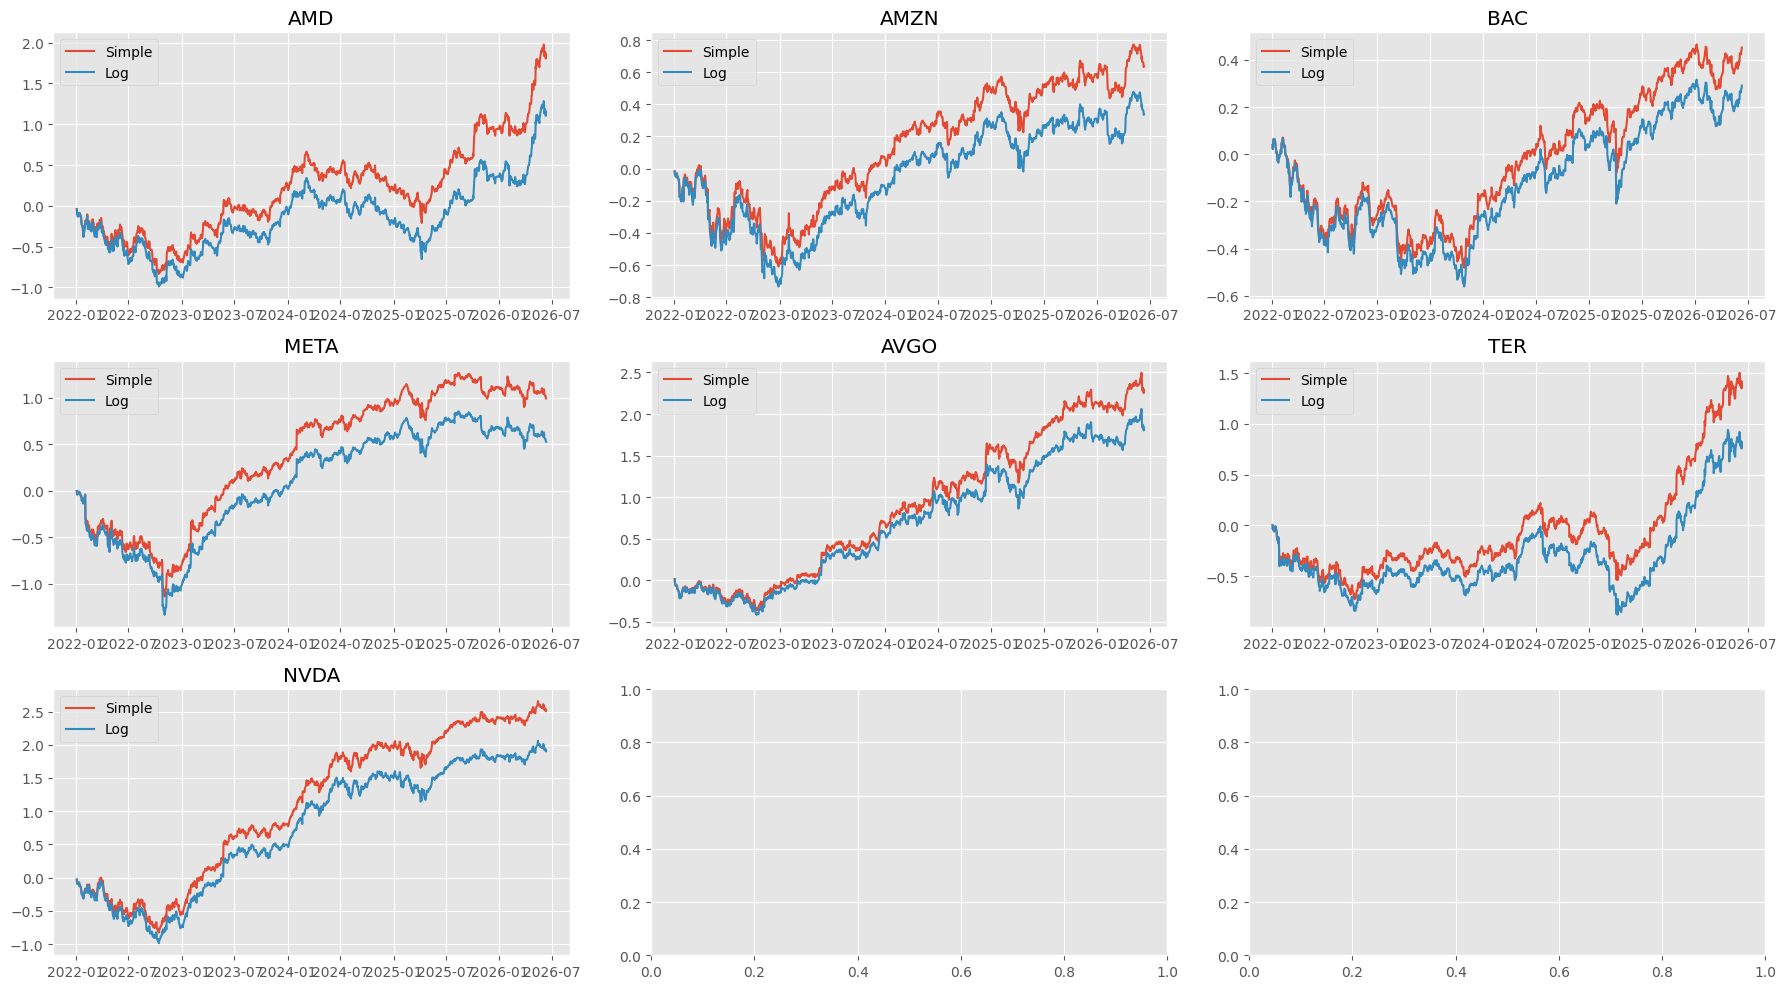

In [38]:
fig, axs = plt.subplots(3, 3, figsize=(18, 10))
axs = axs.flatten()

for i, ticker in enumerate(tickers):
    axs[i].plot(df_res[f'{ticker}_simp_ret'].cumsum(), label='Simple')
    axs[i].plot(df_res[f'{ticker}_log_ret'].cumsum(), label='Log')
    axs[i].set_title(f'{ticker}')
    axs[i].legend()

plt.tight_layout();

## Correlation and Covariation

Prices are **not stationary** (they have a trend), so any two prices will correlate simply due to general market growth/inflation

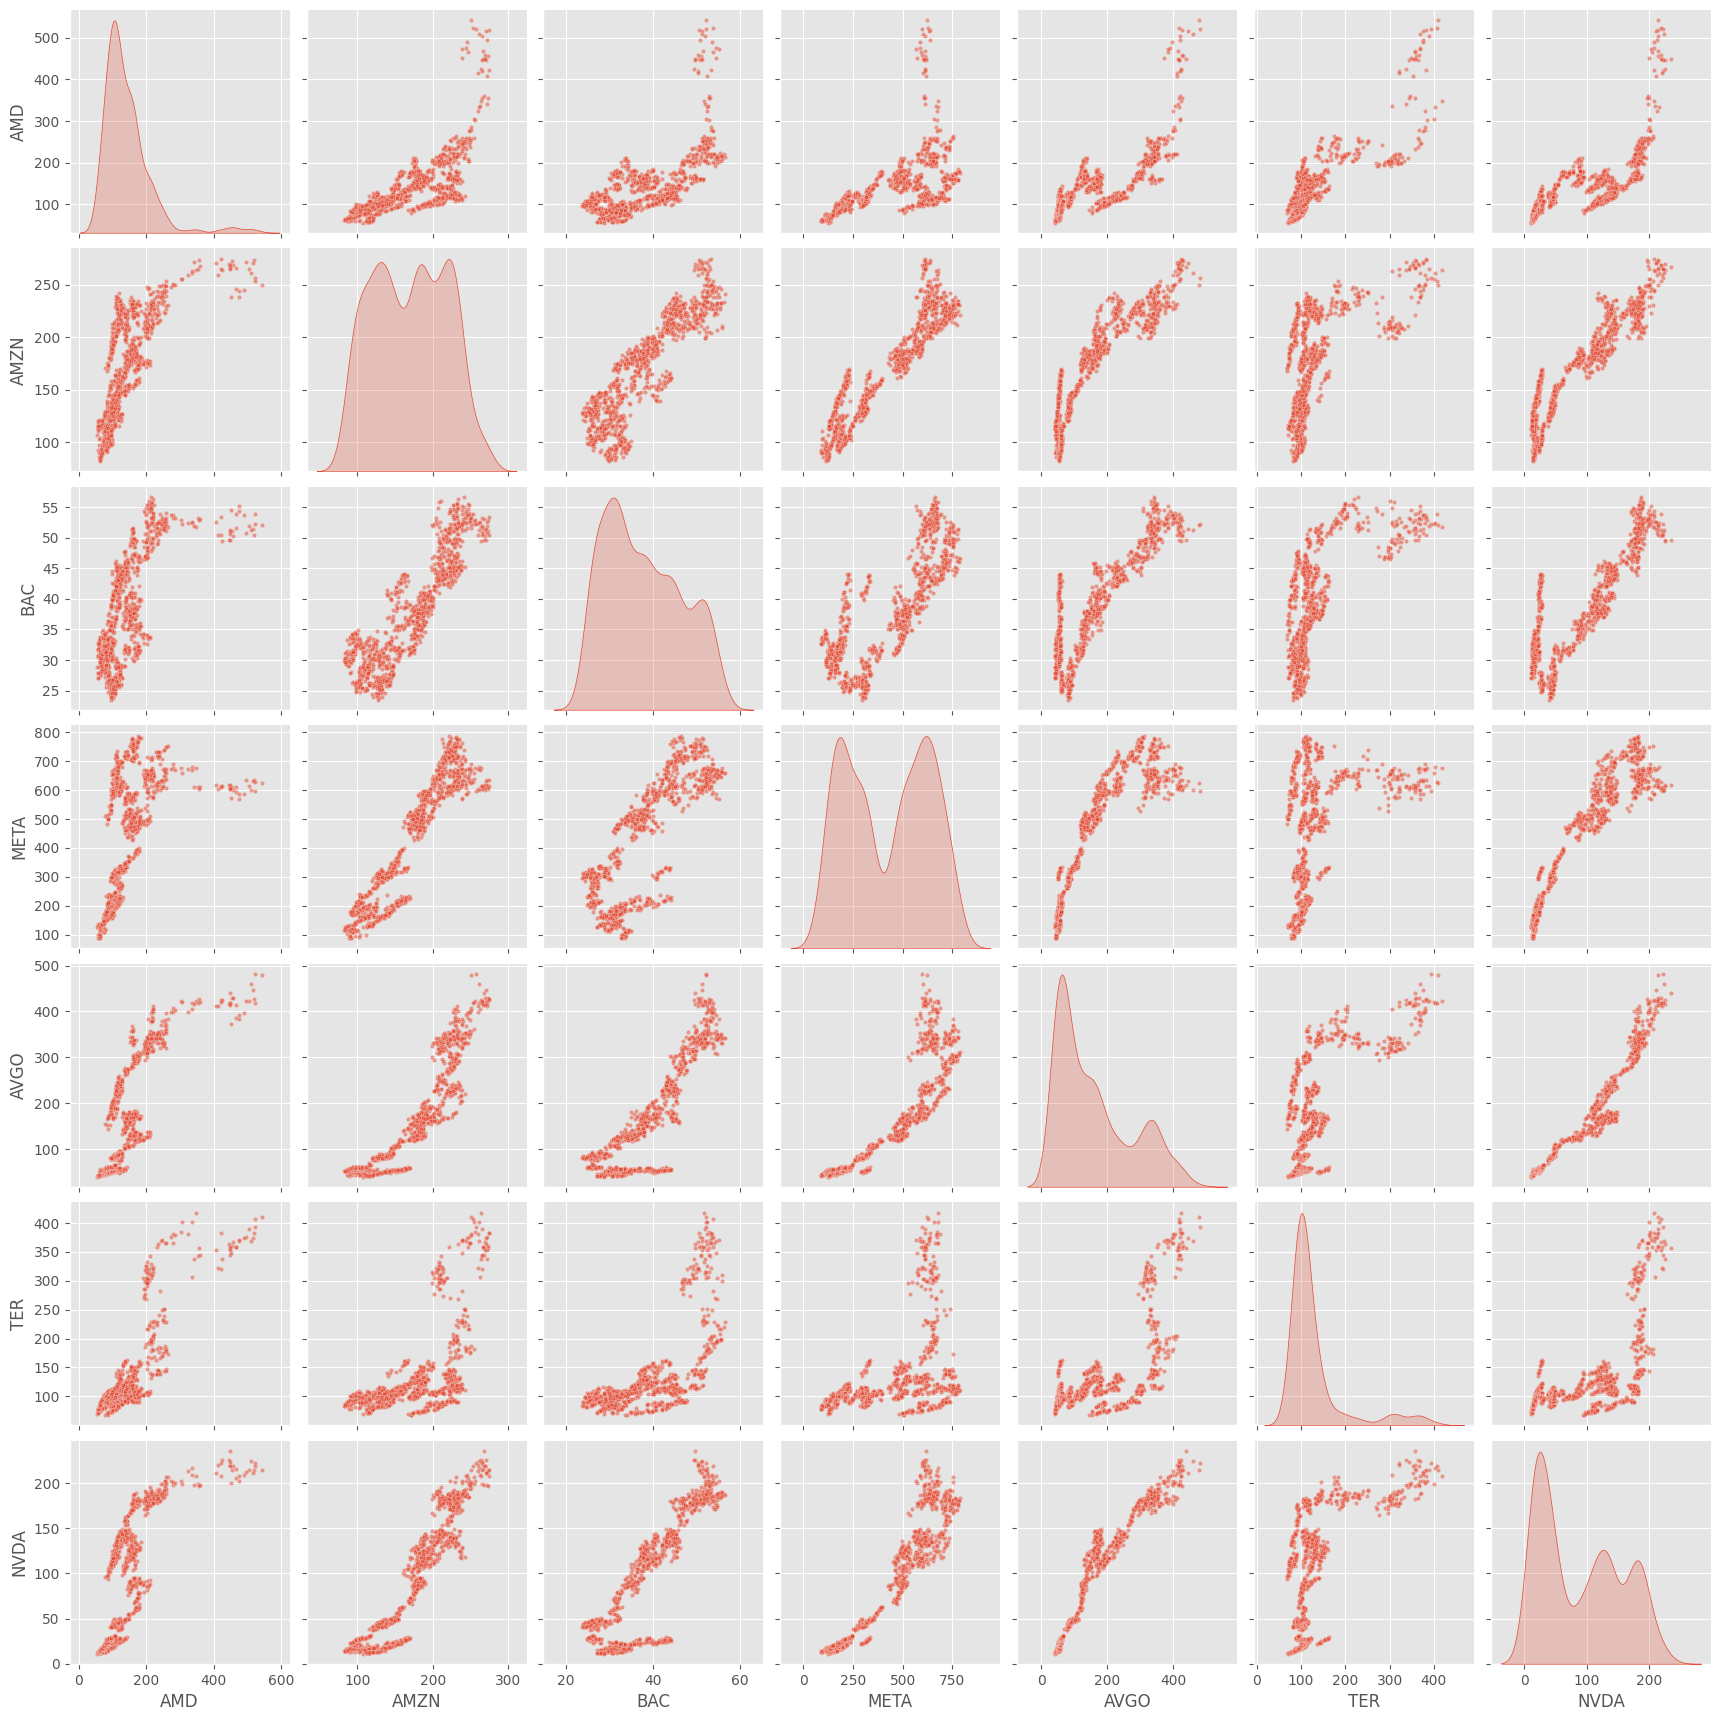

In [50]:
sns.pairplot(df_res[tickers],
            diag_kind='kde', kind='scatter',
            plot_kws={'alpha': 0.5, 's': 10}, diag_kws={'fill': True})


<Axes: xlabel='Ticker', ylabel='Ticker'>

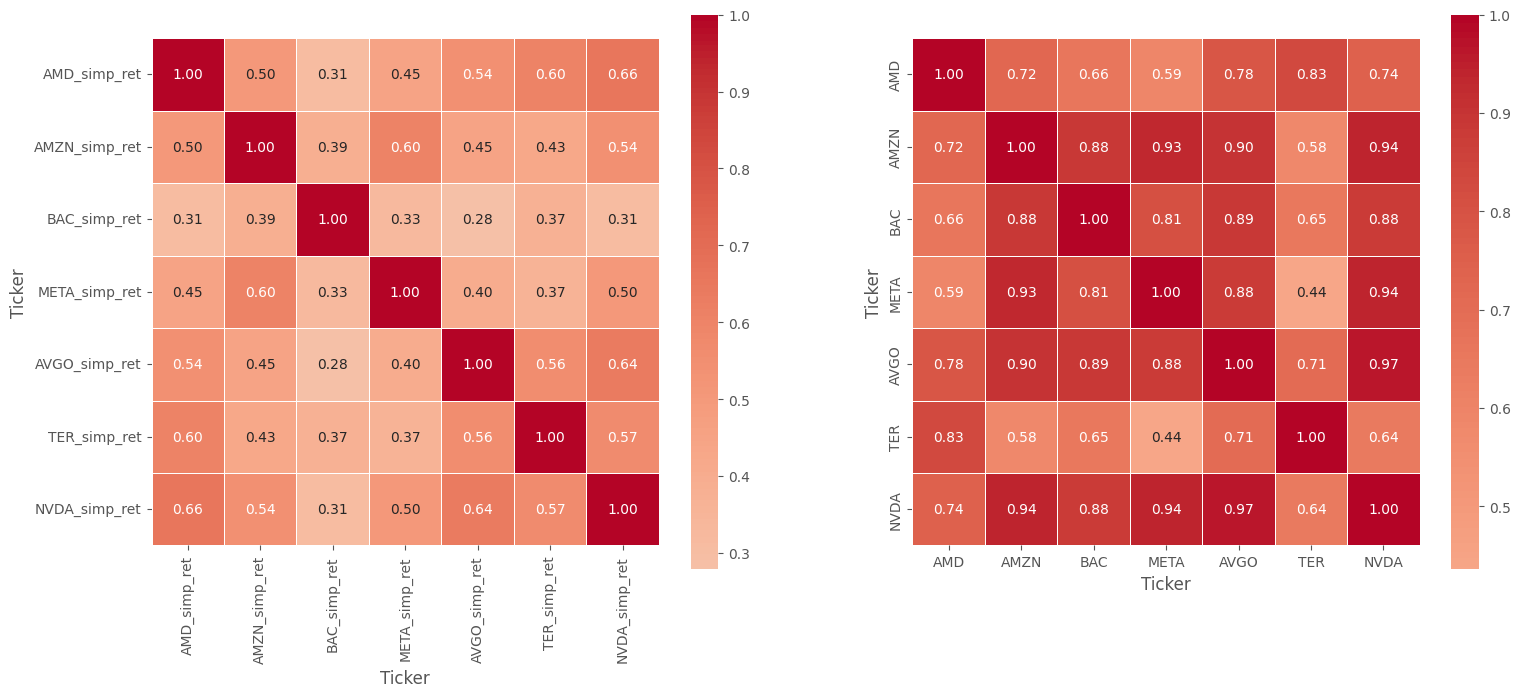

In [71]:
corr_matrix_simp_ret = df_res[[ticker+'_simp_ret' for ticker in tickers]].corr()
corr_matrix_log_ret = df_res[[ticker+'_log_ret' for ticker in tickers]].corr()

fig, axs = plt.subplots(1, 2, figsize=(18, 9))
sns.heatmap(corr_matrix_simp_ret,
            annot=True,
            cmap='coolwarm', center=0,
            fmt='.2f', square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8}, ax=axs[0])
sns.heatmap(df[tickers].corr(),
            annot=True,
            cmap='coolwarm', center=0,
            fmt='.2f', square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8}, ax=axs[1])

<Axes: >

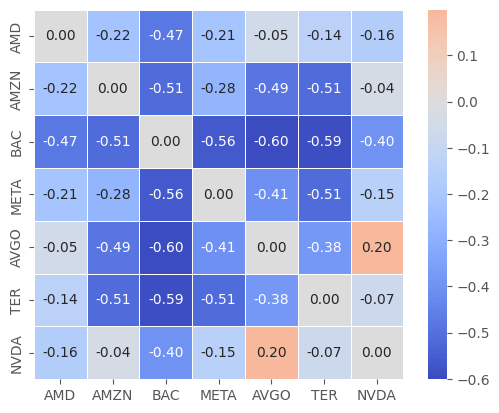

In [70]:
diff = pd.DataFrame(
    data=corr_matrix_simp_ret.to_numpy() - df.corr().to_numpy(),
    index=tickers, columns=tickers
)

sns.heatmap(diff,
            annot=True,
            cmap='coolwarm', center=0,
            fmt='.2f', square=True,
            linewidths=0.5,)